# Student Performance Prediction Using Machine Learning

## AI Mini Project

### Group Members
- Member 1 KUKU BUTROUS IBRAHIM
#- Member 2 
#- Member 3
#- Member 4
#- Member 5

---

## Objective

Develop a machine learning model capable of predicting whether a student will pass or fail based on demographic, social, and academic factors.

---

## AI Task

Classification

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv("../data/student-mat.csv", sep=";")

# Display first five rows
df.head()

,"school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3"
0,"GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mot..."
1,"GP,F,17,U,GT3,T,1,1,at_home,other,course,fathe..."
2,"GP,F,15,U,LE3,T,1,1,at_home,other,other,mother..."
3,"GP,F,15,U,GT3,T,4,2,health,services,home,mothe..."
4,"GP,F,16,U,GT3,T,3,3,other,other,home,father,1,..."


In [3]:
# Shape of dataset
print("Rows and Columns:", df.shape)

print("\n")

# Dataset information
df.info()

Rows and Columns: (395, 1)


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                               Non-Null Count  Dtype
---  ------                                                                                                                                                                                                                               --------------  -----
 0   school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3  395 non-null    str  
dtypes: str(1)
memory usage: 43.6 KB


In [4]:
# Display first 10 rows
df.head(10)

,"school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3"
0,"GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mot..."
1,"GP,F,17,U,GT3,T,1,1,at_home,other,course,fathe..."
2,"GP,F,15,U,LE3,T,1,1,at_home,other,other,mother..."
3,"GP,F,15,U,GT3,T,4,2,health,services,home,mothe..."
4,"GP,F,16,U,GT3,T,3,3,other,other,home,father,1,..."
5,"GP,M,16,U,LE3,T,4,3,services,other,reputation,..."
6,"GP,M,16,U,LE3,T,2,2,other,other,home,mother,1,..."
7,"GP,F,17,U,GT3,A,4,4,other,teacher,home,mother,..."
8,"GP,M,15,U,LE3,A,3,2,services,other,home,mother..."
9,"GP,M,15,U,GT3,T,3,4,other,other,home,mother,1,..."


In [5]:
df.columns

Index(['school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3'], dtype='str')

In [6]:
df.dtypes

school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3    str
dtype: object

In [7]:
df.describe()

,"school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3"
count,395
unique,395
top,"GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mot..."
freq,1


In [8]:
df.isnull().sum()

school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3    0
dtype: int64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [18]:
# Ensure G3 column exists; if not, try to fix parsing or reload with automatic separator detection
if 'G3' not in df.columns:
	if df.shape[1] == 1:
		# split the single column by commas
		tmp = df.iloc[:, 0].str.split(',', expand=True)
		first_row = tmp.iloc[0].tolist()
		if 'G3' in first_row:
			tmp.columns = first_row
			df = tmp[1:].reset_index(drop=True)
		else:
			# fallback: reload file letting pandas infer the separator
			df = pd.read_csv("../data/student-mat.csv", sep=None, engine='python', skipinitialspace=True)
	else:
		df = pd.read_csv("../data/student-mat.csv", sep=None, engine='python', skipinitialspace=True)

# Create target variable from the final grade
df["Pass"] = (df["G3"].astype(float) >= 10).astype(int)

# Display class distribution
df["Pass"].value_counts()

Pass
1    265
0    130
Name: count, dtype: int64

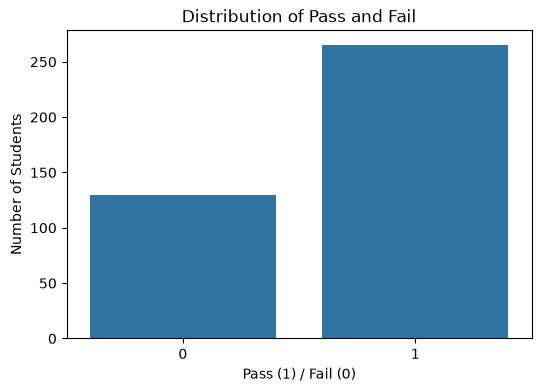

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pass")

plt.title("Distribution of Pass and Fail")
plt.xlabel("Pass (1) / Fail (0)")
plt.ylabel("Number of Students")

plt.show()

In [12]:
df.columns

Index(['school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3'], dtype='str')

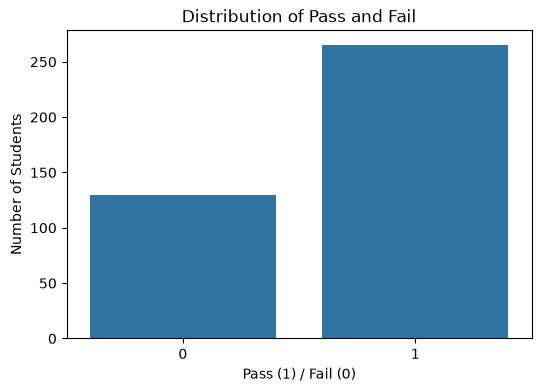

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Pass")
plt.title("Distribution of Pass and Fail")
plt.xlabel("Pass (1) / Fail (0)")
plt.ylabel("Number of Students")
plt.show()

In [20]:
print(df.shape)

(395, 34)


In [21]:
df.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3',
 'Pass']

In [23]:
df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,1
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,1
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,1
5,GP,M,16,U,LE3,T,4,3,services,other,reputation,mother,1,2,0,no,yes,yes,yes,yes,yes,yes,no,5,4,2,1,2,5,10,15,15,15,1
6,GP,M,16,U,LE3,T,2,2,other,other,home,mother,1,2,0,no,no,no,no,yes,yes,yes,no,4,4,4,1,1,3,0,12,12,11,1
7,GP,F,17,U,GT3,A,4,4,other,teacher,home,mother,2,2,0,yes,yes,no,no,yes,yes,no,no,4,1,4,1,1,1,6,6,5,6,0
8,GP,M,15,U,LE3,A,3,2,services,other,home,mother,1,2,0,no,yes,yes,no,yes,yes,yes,no,4,2,2,1,1,1,0,16,18,19,1
9,GP,M,15,U,GT3,T,3,4,other,other,home,mother,1,2,0,no,yes,yes,yes,yes,yes,yes,no,5,5,1,1,1,5,0,14,15,15,1


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [25]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
Pass          0
dtype: int64

In [26]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [27]:
from sklearn.preprocessing import LabelEncoder

# Create a copy
df_encoded = df.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Encode all categorical columns
for column in df_encoded.select_dtypes(include='object').columns:
    df_encoded[column] = le.fit_transform(df_encoded[column])

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [30]:
df_encoded.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,0,0,18,1,0,0,4,4,0,4,0,1,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,6,5,6,6,0
1,0,0,17,1,0,1,1,1,0,2,0,0,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,4,5,5,6,0
2,0,0,15,1,1,1,1,1,0,2,2,1,1,2,3,1,0,1,0,1,1,1,0,4,3,2,2,3,3,10,7,8,10,1
3,0,0,15,1,0,1,4,2,1,3,1,1,1,3,0,0,1,1,1,1,1,1,1,3,2,2,1,1,5,2,15,14,15,1
4,0,0,16,1,0,1,3,3,2,2,1,0,1,2,0,0,1,1,0,1,1,0,0,4,3,2,1,2,5,4,6,10,10,1


In [31]:
# Features
X = df_encoded.drop(columns=["Pass", "G1", "G2", "G3"])

# Target
y = df_encoded["Pass"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (395, 30)
Target vector shape: (395,)


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (316, 30)
Testing samples: (79, 30)


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


In [34]:
# Display the first five records
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,1
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,1
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,1


In [35]:
# Summary statistics
df.describe(include='all')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
count,395,395,395.000000,395,395,395,395.000000,395.000000,395,395,395,395,395.000000,395.000000,395.000000,395,395,395,395,395,395,395,395,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,4,3,NaN,NaN,NaN,2,2,2,2,2,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,course,mother,NaN,NaN,NaN,no,yes,no,yes,yes,yes,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,349,208,NaN,307,281,354,NaN,NaN,141,217,145,273,NaN,NaN,NaN,344,242,214,201,314,375,329,263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.696203,NaN,NaN,NaN,2.749367,2.521519,NaN,NaN,NaN,NaN,1.448101,2.035443,0.334177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190,0.670886
std,NaN,NaN,1.276043,NaN,NaN,NaN,1.094735,1.088201,NaN,NaN,NaN,NaN,0.697505,0.839240,0.743651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443,0.470487
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000,0.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,NaN,NaN,1.000000,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000,1.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,NaN,NaN,2.000000,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000,1.000000


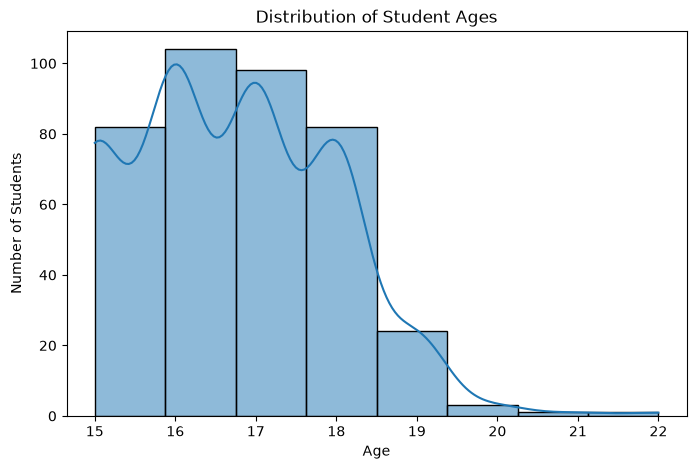

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=8, kde=True)

plt.title("Distribution of Student Ages")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

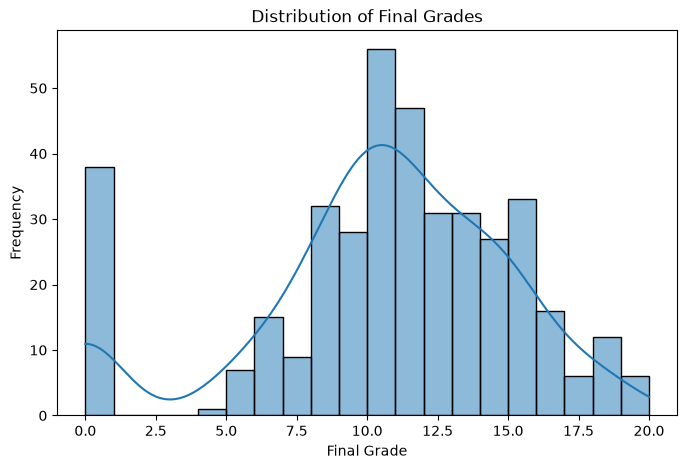

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(df["G3"].astype(float), bins=20, kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Frequency")

plt.show()

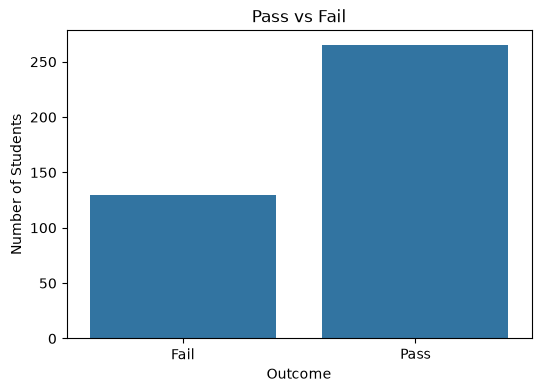

In [38]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pass")

plt.title("Pass vs Fail")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")

plt.xticks([0,1],["Fail","Pass"])

plt.show()

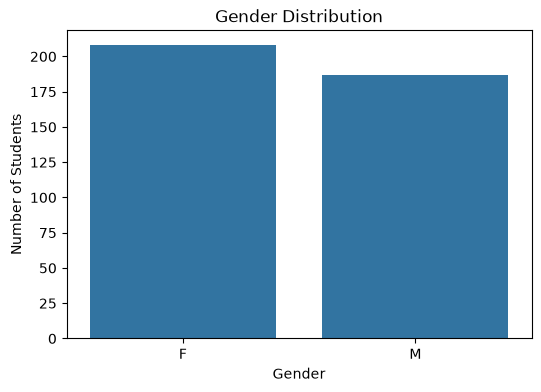

In [39]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="sex")

plt.title("Gender Distribution")

plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.show()

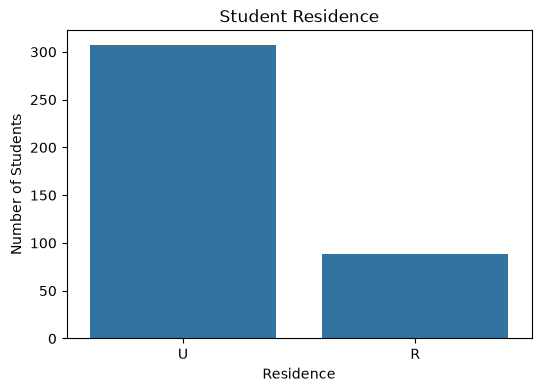

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="address")

plt.title("Student Residence")

plt.xlabel("Residence")
plt.ylabel("Number of Students")

plt.show()

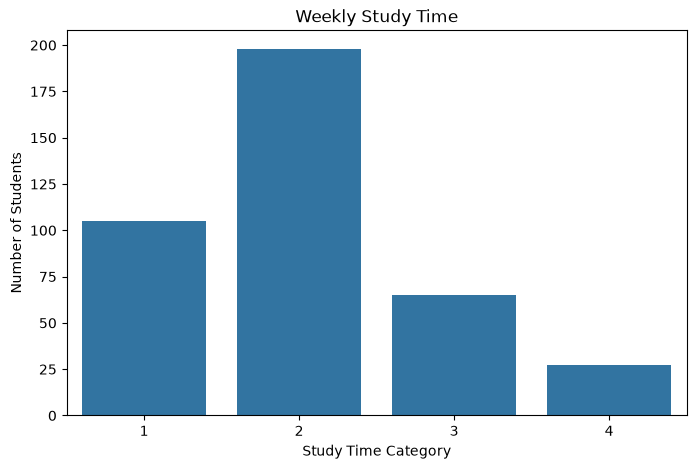

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="studytime")

plt.title("Weekly Study Time")

plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

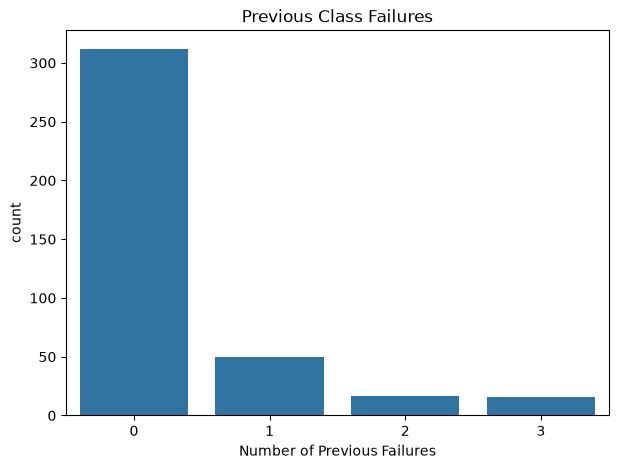

In [42]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="failures")

plt.title("Previous Class Failures")

plt.xlabel("Number of Previous Failures")

plt.show()

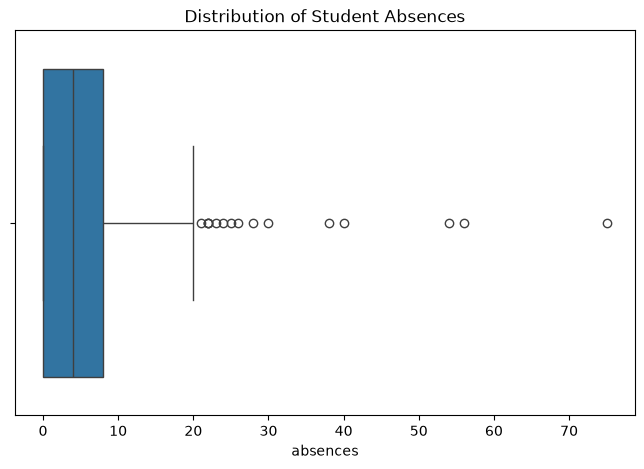

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["absences"].astype(float))

plt.title("Distribution of Student Absences")

plt.show()

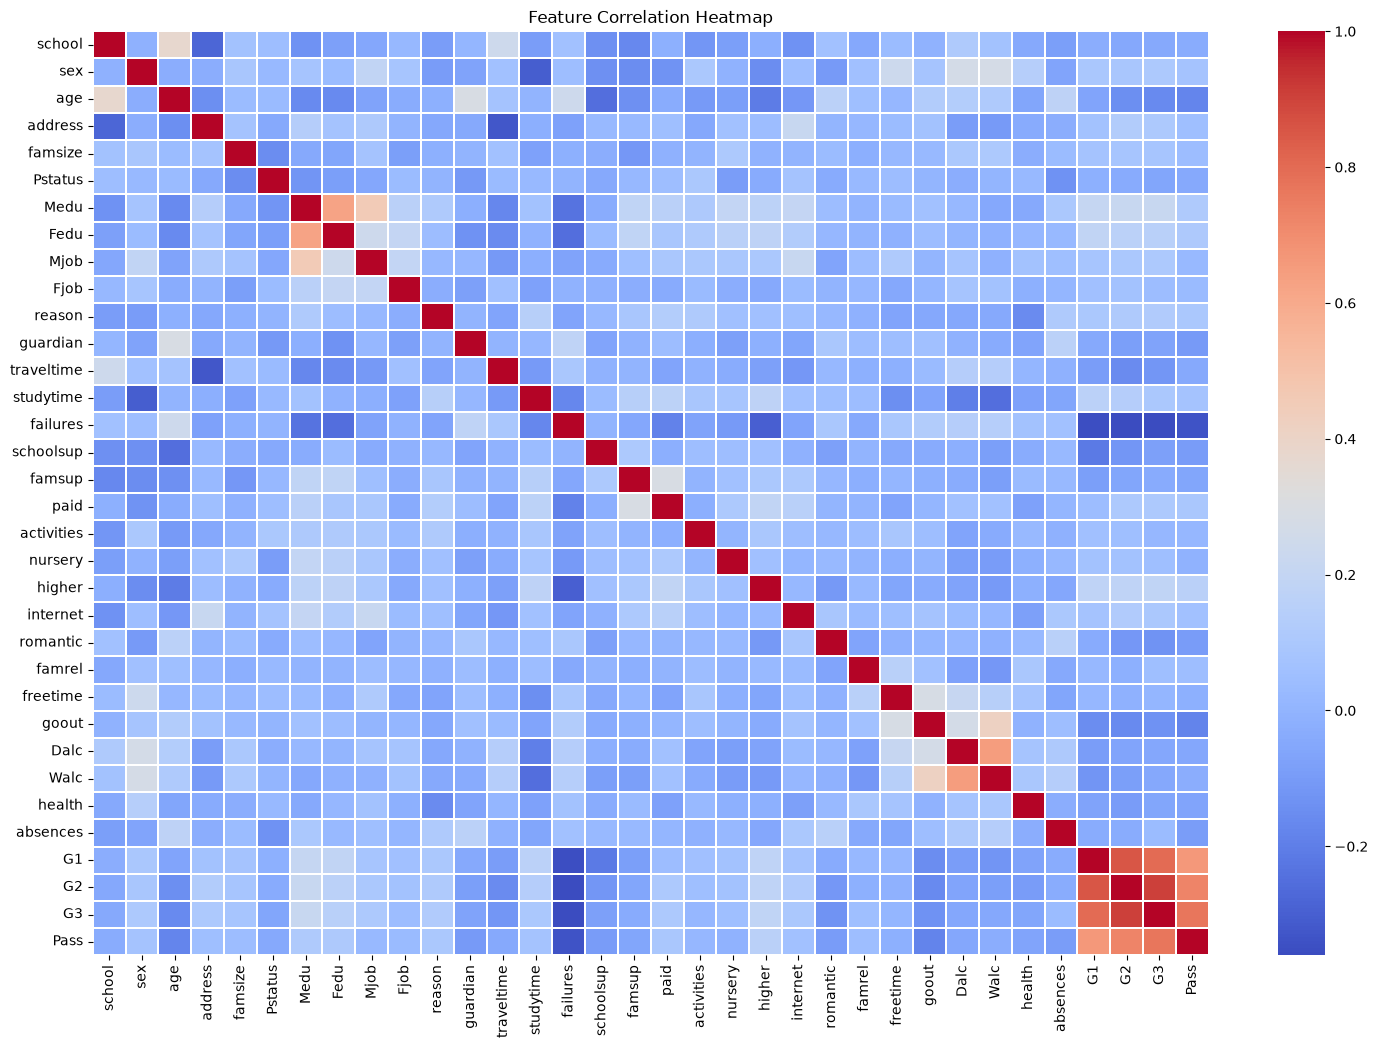

In [44]:
plt.figure(figsize=(18,12))

correlation = df_encoded.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    linewidths=0.3
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [45]:
corr = df_encoded.corr()["Pass"].sort_values(ascending=False)

print(corr)

Pass          1.000000
G3            0.770042
G2            0.725407
G1            0.664979
higher        0.157708
Medu          0.115396
Fedu          0.108057
reason        0.099300
paid          0.092665
studytime     0.074613
sex           0.070618
internet      0.061791
address       0.052282
famrel        0.046683
famsize       0.041842
Fjob          0.028309
Mjob          0.026592
activities    0.012414
nursery      -0.008784
freetime     -0.018321
Walc         -0.029957
school       -0.031254
Pstatus      -0.044050
traveltime   -0.044446
Dalc         -0.057343
famsup       -0.059219
health       -0.065668
absences     -0.092244
romantic     -0.097737
schoolsup    -0.099860
guardian     -0.101407
age          -0.179645
goout        -0.183399
failures     -0.337731
Name: Pass, dtype: float64


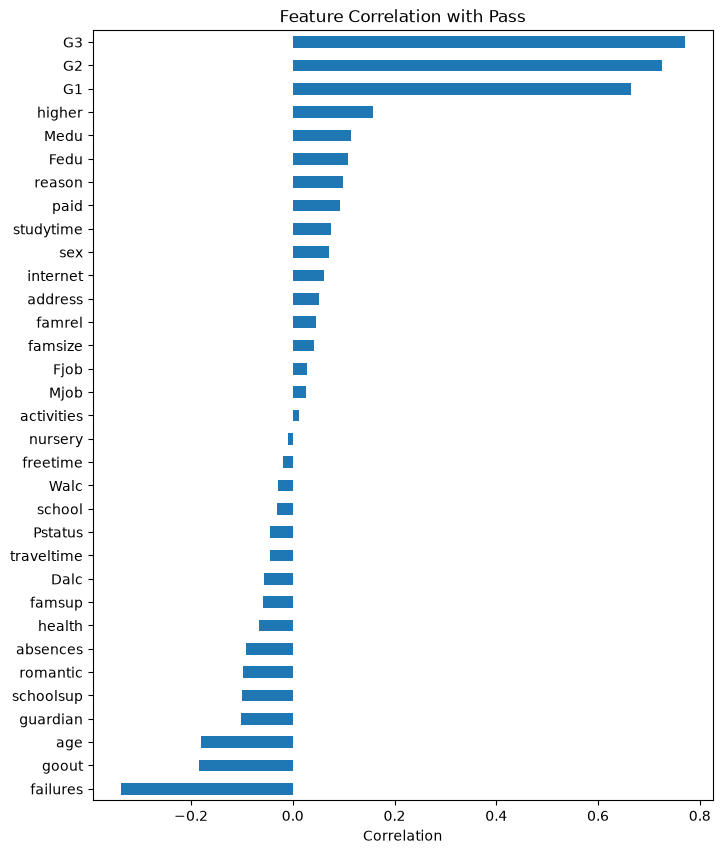

In [46]:
plt.figure(figsize=(8,10))

corr.drop("Pass").sort_values().plot(kind="barh")

plt.title("Feature Correlation with Pass")

plt.xlabel("Correlation")

plt.show()

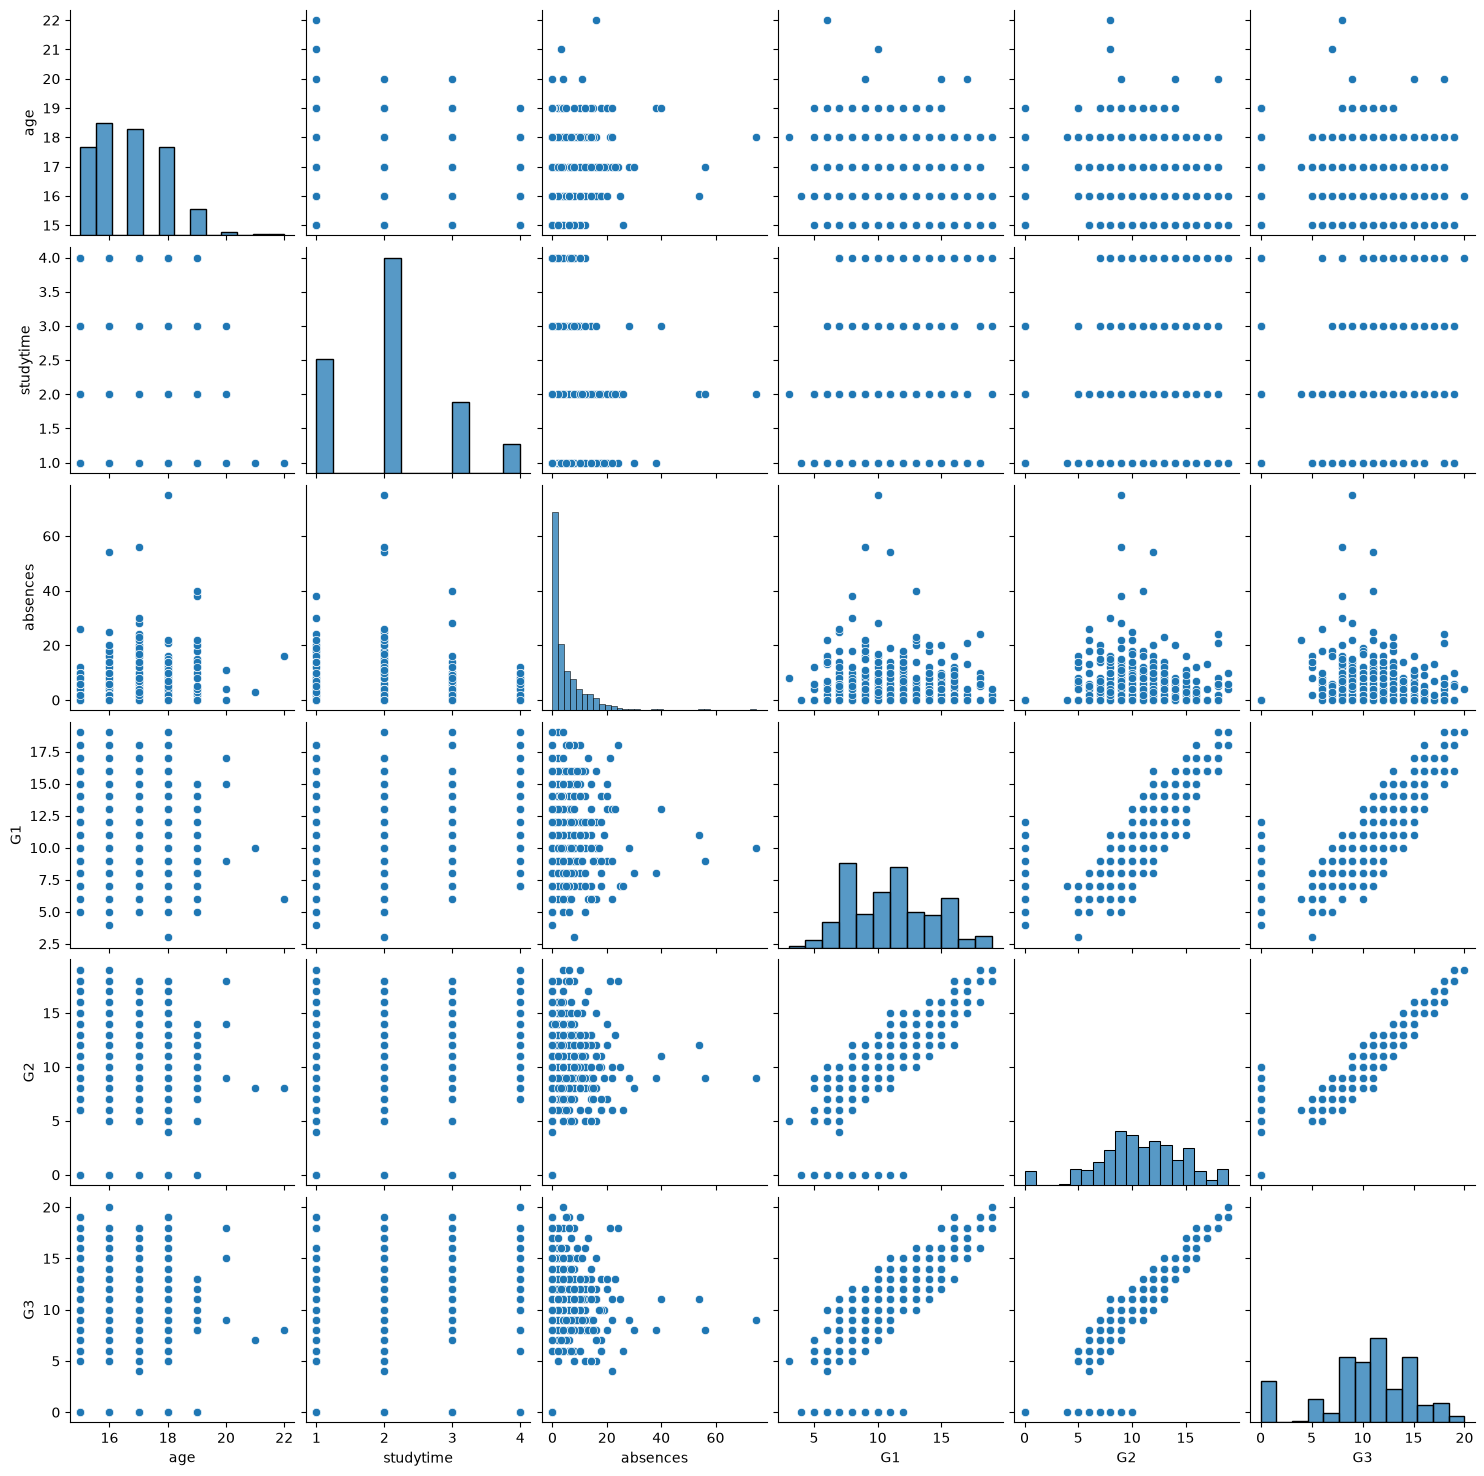

In [47]:
sns.pairplot(
    df[["age","studytime","absences","G1","G2","G3"]],
    diag_kind="hist"
)

plt.show()

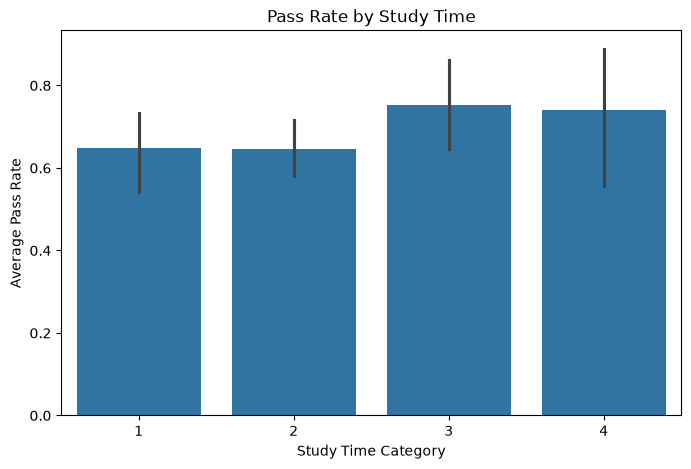

In [48]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="studytime",
    y="Pass"
)

plt.title("Pass Rate by Study Time")

plt.xlabel("Study Time Category")
plt.ylabel("Average Pass Rate")

plt.show()